<a href="https://colab.research.google.com/github/Virkhow/Test_Guide/blob/Upload-file/%D0%98%D0%B2%D0%AD_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np


In [168]:
#Получение данных из Википедии
import pandas as pd
import requests

url = "https://ru.wikipedia.org/wiki/%D0%A2%D0%B5%D0%BF%D0%BB%D0%BE%D0%B2%D0%B0%D1%8F_%D1%8D%D0%BD%D0%B5%D1%80%D0%B3%D0%B5%D1%82%D0%B8%D0%BA%D0%B0_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8"

headers = {
    "User-Agent": "Chrome"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text, index_col=0)

id_table = 0
df_power = tables[id_table]

df_power

/tmp/ipykernel_1112/3726720532.py:13: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



,Название ТЭС,"Установленная мощность, МВт",топливо,Годы ввода агрегатов,Собственник,Регион
№,,,,,,
1,Сургутская ГРЭС-2,56871,"попутный нефтяной газ, природный газ",1985—2011,Юнипро,Ханты-Мансийский АО
2,Рефтинская ГРЭС,3800,каменный уголь,1970—1980,Кузбассэнерго,Свердловская область
3,Костромская ГРЭС,3720,природный газ,1969—1980,Интер РАО,Костромская область
4,Пермская ГРЭС,3393,природный газ,1986—2017,Интер РАО,Пермский край
5,Сургутская ГРЭС-1,3333,"попутный нефтяной газ, природный газ",1972—1983,ОГК-2,Ханты-Мансийский АО
6,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ",1973—2016,Интер РАО,Рязанская область
7,Киришская ГРЭС,2595,природный газ,1969—2012,ОГК-2,Ленинградская область
8,Конаковская ГРЭС,2520,природный газ,1964—1968,Энел Россия,Тверская область
9,Ириклинская ГРЭС,2460,природный газ,1970—1979,Интер РАО,Оренбургская область


#Сортировка данных

In [169]:
df_power_sort1 = df_power.copy()

df_power_sort1 = df_power_sort1.sort_values(['Собственник'])
df_power_sort1

,Название ТЭС,"Установленная мощность, МВт",топливо,Годы ввода агрегатов,Собственник,Регион
№,,,,,,
3,Костромская ГРЭС,3720,природный газ,1969—1980,Интер РАО,Костромская область
4,Пермская ГРЭС,3393,природный газ,1986—2017,Интер РАО,Пермский край
6,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ",1973—2016,Интер РАО,Рязанская область
9,Ириклинская ГРЭС,2460,природный газ,1970—1979,Интер РАО,Оренбургская область
14,Нижневартовская ГРЭС,2031,попутный нефтяной газ,1993—2014,Интер РАО,Ханты-Мансийский АО
2,Рефтинская ГРЭС,3800,каменный уголь,1970—1980,Кузбассэнерго,Свердловская область
5,Сургутская ГРЭС-1,3333,"попутный нефтяной газ, природный газ",1972—1983,ОГК-2,Ханты-Мансийский АО
7,Киришская ГРЭС,2595,природный газ,1969—2012,ОГК-2,Ленинградская область
10,Ставропольская ГРЭС,2423,природный газ,1975—1983,ОГК-2,Ставропольский край


In [170]:
df_power_sort2 = df_power.copy()

df_power_sort2 = df_power_sort2.sort_values(['Установленная мощность, МВт'], ascending = True)
df_power_sort2

,Название ТЭС,"Установленная мощность, МВт",топливо,Годы ввода агрегатов,Собственник,Регион
№,,,,,,
14,Нижневартовская ГРЭС,2031,попутный нефтяной газ,1993—2014,Интер РАО,Ханты-Мансийский АО
12,Новочеркасская ГРЭС,2258,"каменный уголь, природный газ",1965—2016,ОГК-2,Ростовская область
11,Берёзовская ГРЭС,2420,бурый уголь,1987—2015,Юнипро,Красноярский край
10,Ставропольская ГРЭС,2423,природный газ,1975—1983,ОГК-2,Ставропольский край
9,Ириклинская ГРЭС,2460,природный газ,1970—1979,Интер РАО,Оренбургская область
8,Конаковская ГРЭС,2520,природный газ,1964—1968,Энел Россия,Тверская область
7,Киришская ГРЭС,2595,природный газ,1969—2012,ОГК-2,Ленинградская область
6,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ",1973—2016,Интер РАО,Рязанская область
5,Сургутская ГРЭС-1,3333,"попутный нефтяной газ, природный газ",1972—1983,ОГК-2,Ханты-Мансийский АО


#Добавление к таблице столбца с новыми данными, полученным путем преобразований имеющихся.

In [171]:
df_ID = df_power.copy()

id_list = []
for name in df_ID['Название ТЭС']:
    if 'ГРЭС-2' in str(name):
        id_list.append('t-2')
    elif 'ГРЭС-1' in str(name):
        id_list.append('t-1')
    elif 'ГРЭС' in str(name):
        id_list.append('t')
    else:
        id_list.append('')

df_ID.insert(0, 'Id', id_list)

df_ID


,Id,Название ТЭС,"Установленная мощность, МВт",топливо,Годы ввода агрегатов,Собственник,Регион
№,,,,,,,
1,t-2,Сургутская ГРЭС-2,56871,"попутный нефтяной газ, природный газ",1985—2011,Юнипро,Ханты-Мансийский АО
2,t,Рефтинская ГРЭС,3800,каменный уголь,1970—1980,Кузбассэнерго,Свердловская область
3,t,Костромская ГРЭС,3720,природный газ,1969—1980,Интер РАО,Костромская область
4,t,Пермская ГРЭС,3393,природный газ,1986—2017,Интер РАО,Пермский край
5,t-1,Сургутская ГРЭС-1,3333,"попутный нефтяной газ, природный газ",1972—1983,ОГК-2,Ханты-Мансийский АО
6,t,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ",1973—2016,Интер РАО,Рязанская область
7,t,Киришская ГРЭС,2595,природный газ,1969—2012,ОГК-2,Ленинградская область
8,t,Конаковская ГРЭС,2520,природный газ,1964—1968,Энел Россия,Тверская область
9,t,Ириклинская ГРЭС,2460,природный газ,1970—1979,Интер РАО,Оренбургская область


In [172]:
df_power_sortID = df_ID.copy()

df_power_sortID = df_power_sortID.sort_values(['Id'], ascending = True)
df_power_sortID

,Id,Название ТЭС,"Установленная мощность, МВт",топливо,Годы ввода агрегатов,Собственник,Регион
№,,,,,,,
2,t,Рефтинская ГРЭС,3800,каменный уголь,1970—1980,Кузбассэнерго,Свердловская область
3,t,Костромская ГРЭС,3720,природный газ,1969—1980,Интер РАО,Костромская область
4,t,Пермская ГРЭС,3393,природный газ,1986—2017,Интер РАО,Пермский край
6,t,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ",1973—2016,Интер РАО,Рязанская область
7,t,Киришская ГРЭС,2595,природный газ,1969—2012,ОГК-2,Ленинградская область
8,t,Конаковская ГРЭС,2520,природный газ,1964—1968,Энел Россия,Тверская область
9,t,Ириклинская ГРЭС,2460,природный газ,1970—1979,Интер РАО,Оренбургская область
10,t,Ставропольская ГРЭС,2423,природный газ,1975—1983,ОГК-2,Ставропольский край
11,t,Берёзовская ГРЭС,2420,бурый уголь,1987—2015,Юнипро,Красноярский край


In [173]:
df_power_2 = df_power_sortID.copy()

df_power_2['выработка_за_сутки'] = df_power_2['Установленная мощность, МВт'] * 24

type_list = []

for name in df_power_2['Название ТЭС']:
    if 'ГРЭС-2' in name:
        type_list.append('ГРЭС-2')
    elif 'ГРЭС-1' in name:
        type_list.append('ГРЭС-1')
    elif 'ГРЭС' in name:
        type_list.append('ГРЭС')
    else:
        type_list.append('?')

df_power_2['тип'] = type_list

df_power_2

,Id,Название ТЭС,"Установленная мощность, МВт",топливо,Годы ввода агрегатов,Собственник,Регион,выработка_за_сутки,тип
№,,,,,,,,,
2,t,Рефтинская ГРЭС,3800,каменный уголь,1970—1980,Кузбассэнерго,Свердловская область,91200,ГРЭС
3,t,Костромская ГРЭС,3720,природный газ,1969—1980,Интер РАО,Костромская область,89280,ГРЭС
4,t,Пермская ГРЭС,3393,природный газ,1986—2017,Интер РАО,Пермский край,81432,ГРЭС
6,t,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ",1973—2016,Интер РАО,Рязанская область,72480,ГРЭС
7,t,Киришская ГРЭС,2595,природный газ,1969—2012,ОГК-2,Ленинградская область,62280,ГРЭС
8,t,Конаковская ГРЭС,2520,природный газ,1964—1968,Энел Россия,Тверская область,60480,ГРЭС
9,t,Ириклинская ГРЭС,2460,природный газ,1970—1979,Интер РАО,Оренбургская область,59040,ГРЭС
10,t,Ставропольская ГРЭС,2423,природный газ,1975—1983,ОГК-2,Ставропольский край,58152,ГРЭС
11,t,Берёзовская ГРЭС,2420,бурый уголь,1987—2015,Юнипро,Красноярский край,58080,ГРЭС


# Выбор фрагмента таблицы по условию.

In [174]:
# Выбрать электростанции с мощностью выше 3500 МВт и относящиеся НЕ к ГРЭС-1  -2

df_power_3000 = df_power_2.copy()

df_power_3000 = df_power_3000[(df_power_3000['Установленная мощность, МВт'] > 3000.) & ~((df_power_3000.тип == 'ГРЭС-1') | (df_power_3000.тип == 'ГРЭС-2'))]

df_power_3000

,Id,Название ТЭС,"Установленная мощность, МВт",топливо,Годы ввода агрегатов,Собственник,Регион,выработка_за_сутки,тип
№,,,,,,,,,
2,t,Рефтинская ГРЭС,3800,каменный уголь,1970—1980,Кузбассэнерго,Свердловская область,91200,ГРЭС
3,t,Костромская ГРЭС,3720,природный газ,1969—1980,Интер РАО,Костромская область,89280,ГРЭС
4,t,Пермская ГРЭС,3393,природный газ,1986—2017,Интер РАО,Пермский край,81432,ГРЭС
6,t,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ",1973—2016,Интер РАО,Рязанская область,72480,ГРЭС
13,t,Заинская ГРЭС,22049,природный газ,1963—1972,Татэнерго,Татарстан,529176,ГРЭС


# Выбор фрагмента таблицы по номерам строк и столбцов

In [175]:
df_power_sc = df_power_sort2.copy()

df_power_sc = df_power_sc.iloc[:-2, :3]

df_power_sc


,Название ТЭС,"Установленная мощность, МВт",топливо
№,,,
14,Нижневартовская ГРЭС,2031,попутный нефтяной газ
12,Новочеркасская ГРЭС,2258,"каменный уголь, природный газ"
11,Берёзовская ГРЭС,2420,бурый уголь
10,Ставропольская ГРЭС,2423,природный газ
9,Ириклинская ГРЭС,2460,природный газ
8,Конаковская ГРЭС,2520,природный газ
7,Киришская ГРЭС,2595,природный газ
6,Рязанская ГРЭС,3020,"бурый уголь, каменный уголь, природный газ"
5,Сургутская ГРЭС-1,3333,"попутный нефтяной газ, природный газ"


# Расчеты статистических показателей по сгруппированным данным.

In [176]:
# Число электростанций по мощности выше 3000 МВт и разделением по компаниям
df_power_group = df_power_2.copy()

print(df_power_group.groupby(['Собственник', df_power_group['Установленная мощность, МВт'] > 500])['Установленная мощность, МВт'].count())
print()

Собственник    Установленная мощность, МВт
Интер РАО      True                           5
Кузбассэнерго  True                           1
ОГК-2          True                           4
Татэнерго      True                           1
Энел Россия    True                           1
Юнипро         True                           2
Name: Установленная мощность, МВт, dtype: int64



# Построение гистограммы по данным.

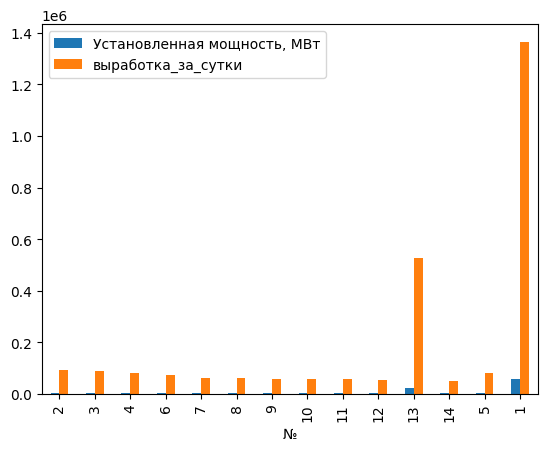

In [177]:
df_power_2.plot(kind = 'bar')
print()

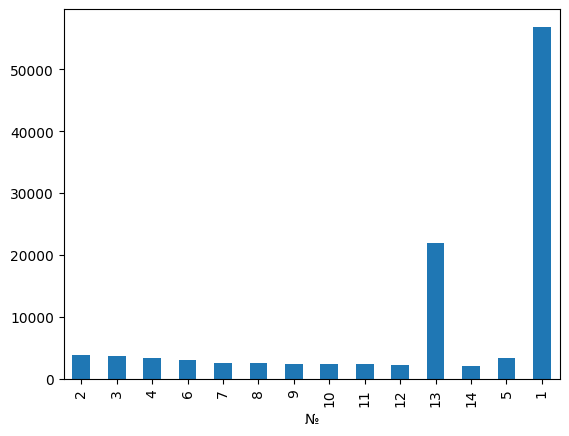

In [178]:
df_power_2['Установленная мощность, МВт'].plot(kind = 'bar')
print()

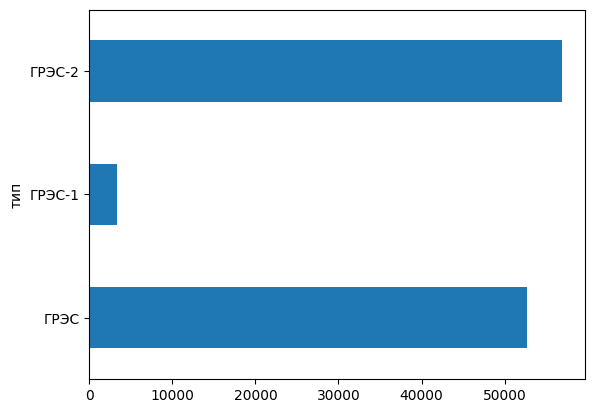

In [179]:
df_power_group.groupby(['тип'])['Установленная мощность, МВт'].sum().plot(kind = 'barh')
print()

# Построение круговой диаграммы по данным.

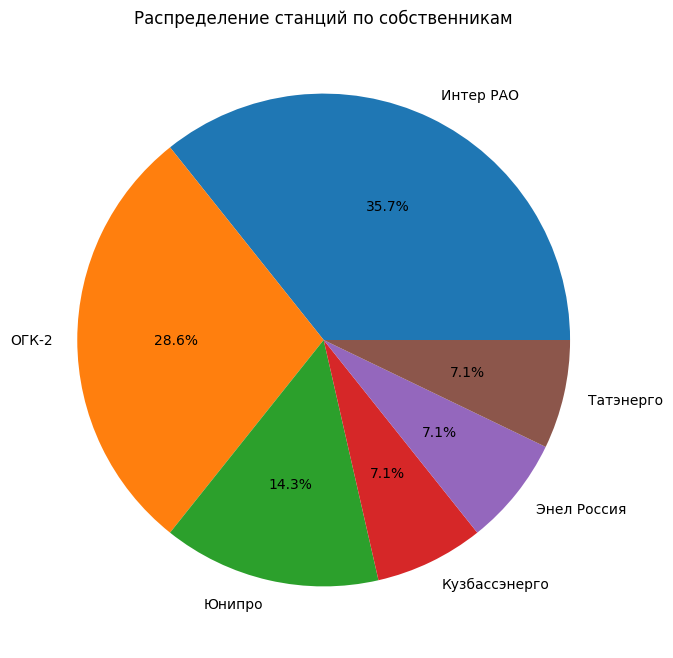

In [180]:
import matplotlib.pyplot as plt

# Считаем количество станций по собственникам
owner_counts = df_power_2['Собственник'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(owner_counts.values, labels=owner_counts.index, autopct='%1.1f%%')
plt.title('Распределение станций по собственникам')
plt.show()

# Построение интерактивного графика по данным.

In [181]:
import plotly.express as px

# Сортируем по мощности
df_sorted = df_power_2.sort_values('Установленная мощность, МВт', ascending=True)

fig = px.line(df_sorted,
              x='Название ТЭС',
              y='Установленная мощность, МВт',
              markers=True,
              title='Мощность станций (сортировка по возрастанию)',
              hover_data=['Собственник', 'тип'])

fig.update_layout(xaxis_tickangle=-30)
fig.show()

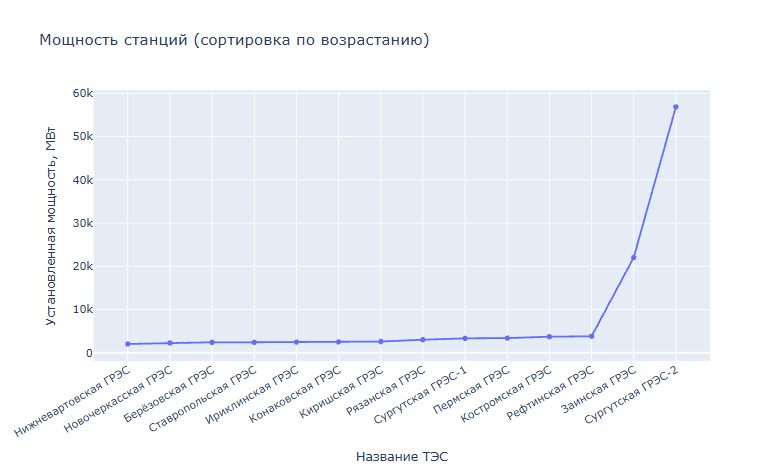